In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

In [2]:
# Load dataset
data = pd.read_csv('Sentiment_Filtered.csv')

In [3]:
data

,id,text,Sentiment,Label,clean_text
0,1.340000e+18,The agency also released new information for h...,Positive,0.0,agency also released new information health ca...
1,1.340000e+18,The US Food and Drug Administration FDA has gr...,Positive,0.0,us food drug administration fda granted emerge...
2,1.340000e+18,Ive never been so excited to get a vaccine Cov...,Positive,0.0,ive never excited get vaccine covidvaccine pfi...
3,1.340000e+18,UgurSahin ozlemtureci the Muslim Scientists Hu...,Positive,0.0,ugursahin ozlemtureci muslim scientists husban...
4,1.340000e+18,Toronto to receive Ontarios 1st doses of Pfize...,Positive,0.0,toronto receive ontarios st doses pfizer covid...
...,...,...,...,...,...
7567,1.390000e+18,Have Covaxin Phase 3 trial results been publis...,Positive,0.0,covaxin phase trial results published findings...
7568,1.390000e+18,Bharat Biotechs plant in Karnataka to produce ...,Positive,0.0,bharat biotechs plant karnataka produce first ...
7569,1.390000e+18,Covaxin trials for 218 year group to begin in ...,Positive,0.0,covaxin trials year group begin days govt
7570,1.390000e+18,Hope something new comes up soon VaccineForAll...,Positive,0.0,hope something new comes soon vaccineforall va...


In [4]:
# Assuming the dataset has 'clean_text' and 'Label' columns
if 'clean_text' in data.columns and 'Label' in data.columns:
    data = data.dropna(subset=['clean_text', 'Label'])  # Drop rows with missing values
    X = data['clean_text'].fillna("")  # Fill NaN values with empty string
    y = data['Label']
else:
    raise ValueError("Dataset must contain 'clean_text' and 'Label' columns")

In [5]:
data


,id,text,Sentiment,Label,clean_text
0,1.340000e+18,The agency also released new information for h...,Positive,0.0,agency also released new information health ca...
1,1.340000e+18,The US Food and Drug Administration FDA has gr...,Positive,0.0,us food drug administration fda granted emerge...
2,1.340000e+18,Ive never been so excited to get a vaccine Cov...,Positive,0.0,ive never excited get vaccine covidvaccine pfi...
3,1.340000e+18,UgurSahin ozlemtureci the Muslim Scientists Hu...,Positive,0.0,ugursahin ozlemtureci muslim scientists husban...
4,1.340000e+18,Toronto to receive Ontarios 1st doses of Pfize...,Positive,0.0,toronto receive ontarios st doses pfizer covid...
...,...,...,...,...,...
7567,1.390000e+18,Have Covaxin Phase 3 trial results been publis...,Positive,0.0,covaxin phase trial results published findings...
7568,1.390000e+18,Bharat Biotechs plant in Karnataka to produce ...,Positive,0.0,bharat biotechs plant karnataka produce first ...
7569,1.390000e+18,Covaxin trials for 218 year group to begin in ...,Positive,0.0,covaxin trials year group begin days govt
7570,1.390000e+18,Hope something new comes up soon VaccineForAll...,Positive,0.0,hope something new comes soon vaccineforall va...


In [6]:
X

0       agency also released new information health ca...
1       us food drug administration fda granted emerge...
2       ive never excited get vaccine covidvaccine pfi...
3       ugursahin ozlemtureci muslim scientists husban...
4       toronto receive ontarios st doses pfizer covid...
                              ...                        
7567    covaxin phase trial results published findings...
7568    bharat biotechs plant karnataka produce first ...
7569            covaxin trials year group begin days govt
7570    hope something new comes soon vaccineforall va...
7571    government announces clinical trials covaxin a...
Name: clean_text, Length: 7568, dtype: object

In [7]:
# Convert labels to numeric values
le = LabelEncoder()
y = le.fit_transform(y)

In [8]:
# Swap sentiment labels: 0 -> Positive, 1 -> Negative
y = np.where(y == 0, 1, 0)

In [9]:
# Convert text to numerical features (Using TF-IDF for simplicity)
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

In [10]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
print(y_train.head)

[1 1 1 ... 1 1 1]


In [13]:
# Check column existence
if 'y_train' in data.columns:
    sentiment_counts = data['y_train'].value_counts(normalize=True) * 100
    print(sentiment_counts)
else:
    print("Column 'y_train' not found.")

Column 'y_train' not found.


In [19]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Bagging": BaggingClassifier(),
    "XGBoost": XGBClassifier(),
    "MLP Classifier": MLPClassifier(),
    "SVM": SVC()
}

In [20]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 57177 stored elements and shape (6054, 9971)>

In [21]:
# Store results
results = {}

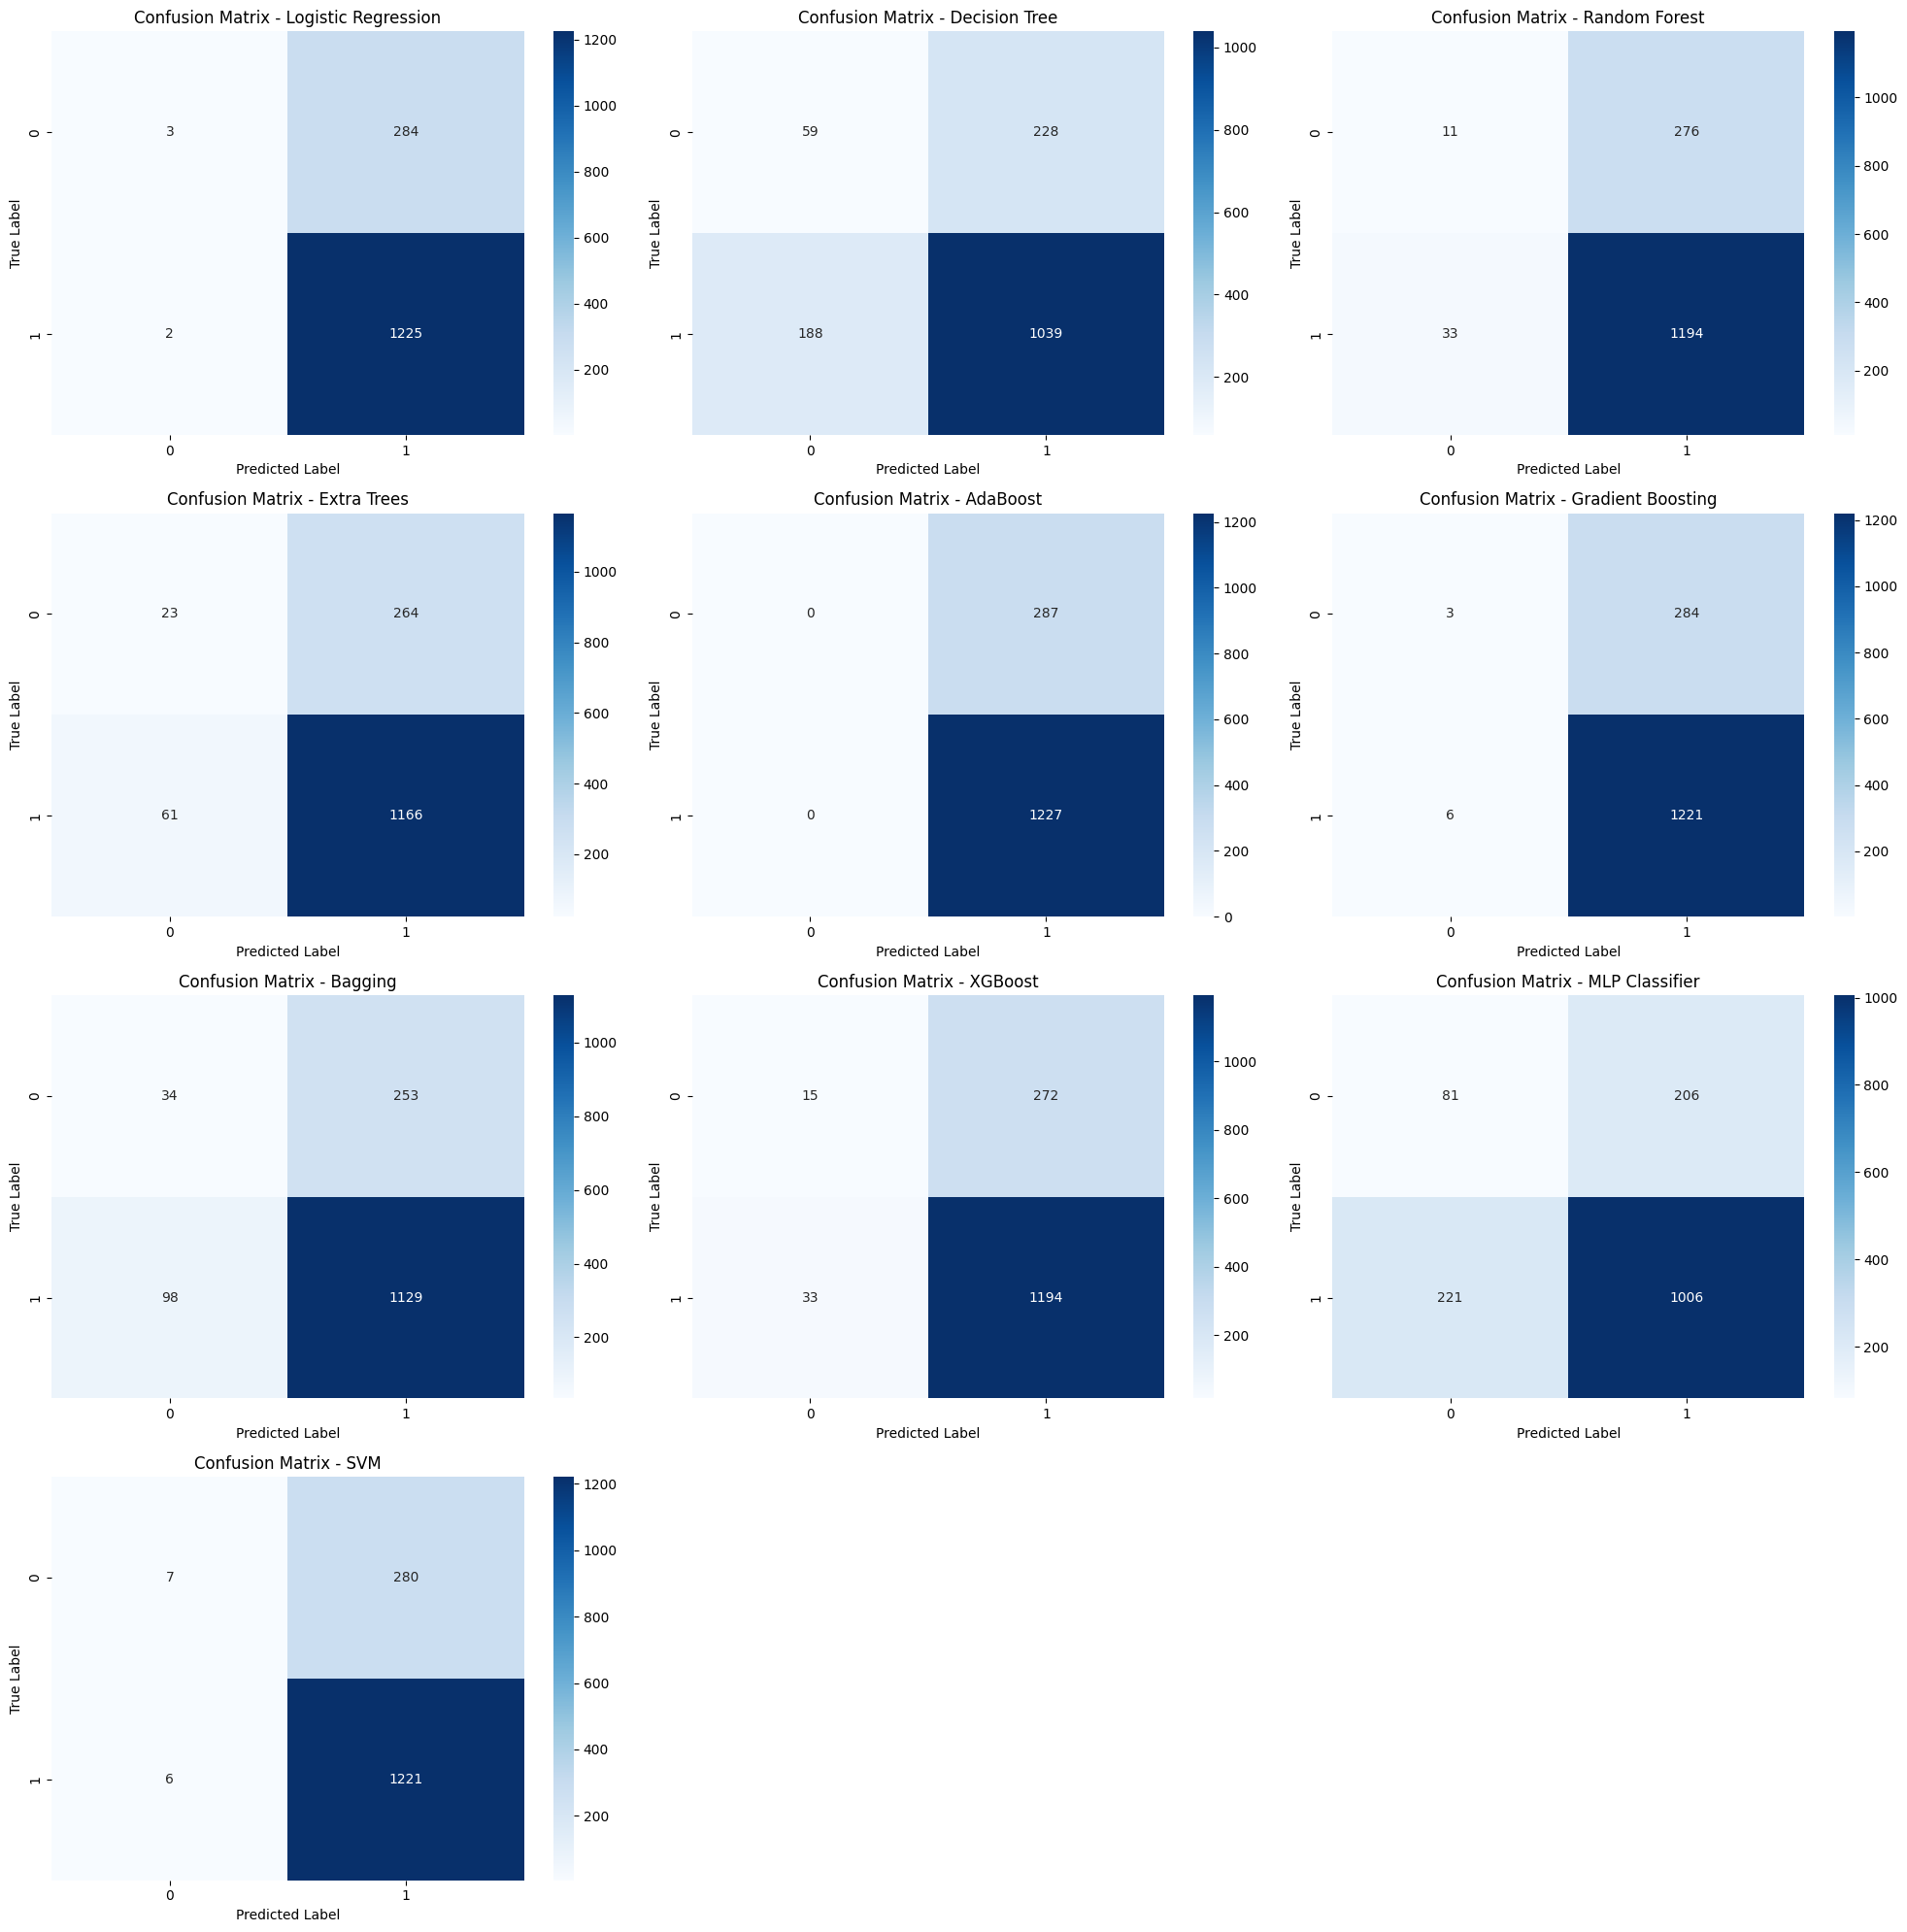

In [22]:
# Plot confusion matrices
plt.figure(figsize=(20, 20))
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = [accuracy, precision, recall, f1]
    
    # Compute and plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(4, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()


In [23]:
# Convert results to DataFrame
results_df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1-score"])

In [15]:
print(results_df)

           Logistic Regression  Decision Tree  Random Forest  Extra Trees  \
Accuracy              0.811096       0.718626       0.796565     0.785997   
Precision             0.771647       0.702002       0.709271     0.714803   
Recall                0.811096       0.718626       0.796565     0.785997   
F1-score              0.729614       0.709887       0.731552     0.736032   

           AdaBoost  Gradient Boosting   Bagging   XGBoost  MLP Classifier  \
Accuracy   0.810436           0.809775  0.774769  0.798547        0.724571   
Precision  0.846370           0.742292  0.719049  0.719307        0.721980   
Recall     0.810436           0.809775  0.774769  0.798547        0.724571   
F1-score   0.725578           0.730125  0.738475  0.735625        0.723262   

                SVM  
Accuracy   0.811096  
Precision  0.761328  
Recall     0.811096  
F1-score   0.734317  


<Figure size 1200x600 with 0 Axes>

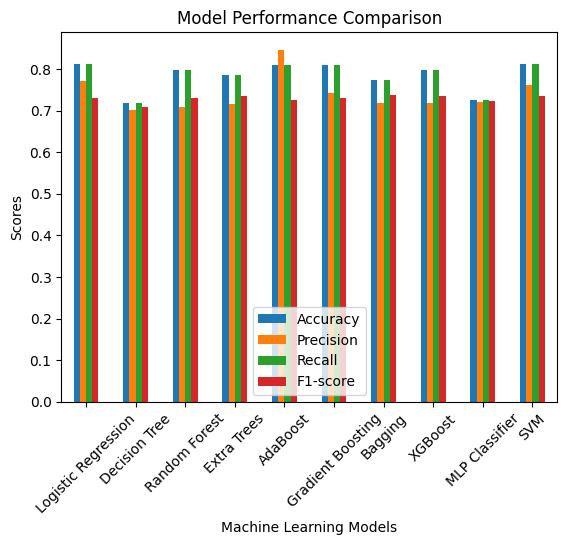

In [16]:
# Plot performance comparison
plt.figure(figsize=(12, 6))
results_df.T.plot(kind='bar')
plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Scores")
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.show()

In [16]:
X_train

NameError: name 'X_train' is not defined